# Investigating Bias in Early Sepsis Prediction
## Objective and Rationale for Choosing Sepsis

The main objective of this study is to develop a machine learning model for early sepsis prediction and then evaluate whether the model behaves fairly across gender groups. The work does not focus only on predictive performance, but also on whether one group may be disadvantaged when the model is applied in a high-risk healthcare setting. To examine this, the final model is assessed using standard classification metrics together with three fairness criteria: equal accuracy, demographic parity, and equal opportunity.

Sepsis was chosen because it is a serious clinical condition where delayed recognition can lead to severe complications or death. This makes it a meaningful application area for an AI ethics study. A model in this setting should not only perform reasonably well overall, but should also avoid unfair differences in how true cases are detected across groups. Sepsis was also a suitable choice because the dataset is large, clinically realistic, and well suited to binary classification, which makes it a strong setting for investigating both model performance and bias.

The workflow I followed throught this notebook;
1. data loading and inspection  
2. feature filtering and preprocessing  
3. patient-level train-test splitting to avoid leakage  
4. baseline modelling  
5. tuned XGBoost as the final selected model  
6. fairness evaluation across gender  
7. an additional XGBoost + SMOTE comparison  
8. comparison visuals  
9. local interpretability with LIME

## Import Libraries

In [39]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay,
)

from imblearn.over_sampling import SMOTE

import lime
import lime.lime_tabular

import jinja2

In [40]:
# Dreamwave theme palette
PALETTE = {
    "primary": "#A18CD1",     # Dreamwave purple
    "secondary": "#FBC2EB",   # Dreamwave pink
    "mid": "#D8B4E2",         # blended pastel purple-pink
    "accent": "#CDB4DB",      # soft lavender
    "light": "#F6EAF4",       # very light pastel
    "dark": "#5F5A67",        # muted dark grey for text/edges
    "grid": "#E9DFF0"         # soft gridline pastel
}

# Global notebook style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": PALETTE["dark"],
    "axes.labelcolor": PALETTE["dark"],
    "xtick.color": PALETTE["dark"],
    "ytick.color": PALETTE["dark"],
    "text.color": PALETTE["dark"],
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 10,
    "grid.color": PALETTE["grid"],
    "grid.linestyle": "--",
    "grid.linewidth": 0.8,
    "legend.frameon": False
})

## Load and Inspect Data

In [41]:

df = pd.read_csv("Dataset.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nTarget distribution:")
print(df["SepsisLabel"].value_counts())

print("\nGender distribution:")
print(df["Gender"].value_counts())

print("\nUnique patients:", df["Patient_ID"].nunique())

missing_pct_initial = df.isnull().mean().sort_values(ascending=False) * 100
print("\nTop missing columns (%):")
print(missing_pct_initial.head(15))

Shape: (1552210, 44)

Columns:
['Unnamed: 0', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']

Target distribution:
SepsisLabel
0    1524294
1      27916
Name: count, dtype: int64

Gender distribution:
Gender
1    868103
0    684107
Name: count, dtype: int64

Unique patients: 40336

Top missing columns (%):
Bilirubin_direct    99.807371
Fibrinogen          99.340167
TroponinI           99.047745
Bilirubin_total     98.509158
Alkalinephos        98.393194
AST                 98.377604
Lactate             97.329872
PTT                 97.055875
SaO2                96.549372
EtCO2               96.

### Dataset Introduction

This dataset contains hourly ICU observations and is suitable for binary classification because the target variable, **SepsisLabel**, is coded as 0 for non-sepsis and 1 for sepsis.  
It also includes **Gender**, which is used as the protected characteristic in the fairness analysis.

## EDA 

This section explores the main characteristics of the sepsis dataset before model development. The analysis focuses on class imbalance, missingness, patient-level structure, feature distributions, and relationships between key variables. These plots help explain the need for feature filtering, careful preprocessing, and imbalance-aware modelling.

In [42]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": PALETTE["dark"],
    "axes.labelcolor": PALETTE["dark"],
    "xtick.color": PALETTE["dark"],
    "ytick.color": PALETTE["dark"],
    "text.color": PALETTE["dark"],
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 10,
    "grid.color": PALETTE["grid"],
    "grid.linestyle": "--",
    "grid.linewidth": 0.8
})

### Class distribution bar chart

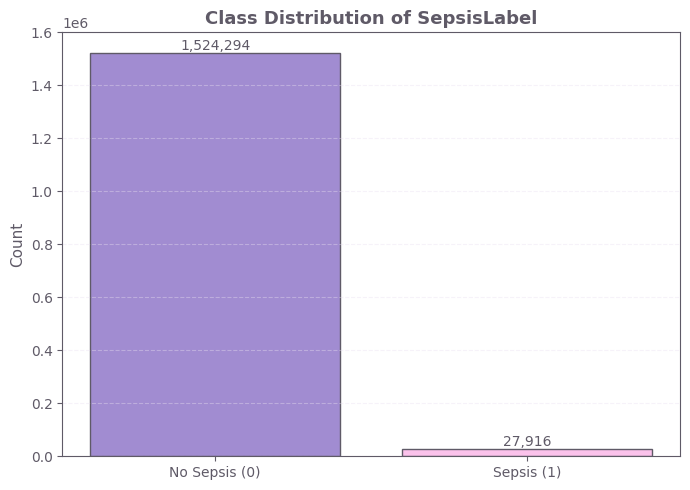

In [43]:
class_counts = df["SepsisLabel"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
bars = plt.bar(
    ["No Sepsis (0)", "Sepsis (1)"],
    class_counts.values,
    color=[PALETTE["primary"], PALETTE["secondary"]],
    edgecolor=PALETTE["dark"]
)

plt.title("Class Distribution of SepsisLabel")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.4)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

The target variable is highly imbalanced, with non-sepsis records greatly outnumbering sepsis-positive cases. This confirms that accuracy alone would not be enough to judge model quality and supports the need for imbalance-aware modelling.

### Missingness across features

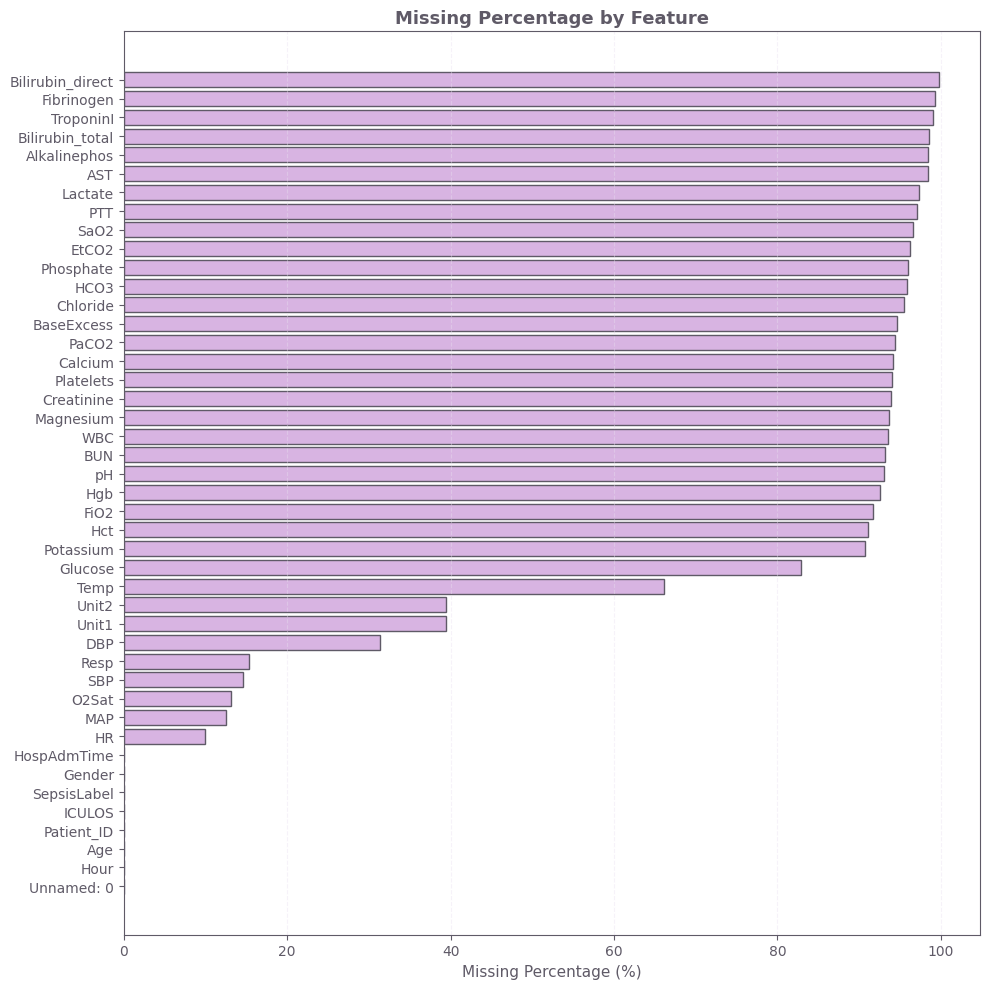

In [44]:
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=True)

plt.figure(figsize=(10, 10))
plt.barh(
    missing_pct.index,
    missing_pct.values,
    color=PALETTE["mid"],
    edgecolor=PALETTE["dark"]
)

plt.title("Missing Percentage by Feature")
plt.xlabel("Missing Percentage (%)")
plt.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.show()

The dataset contains substantial missingness across several clinical variables. This justifies the feature filtering stage and explains why highly sparse variables were removed before model development.

### Patient-level record distribution

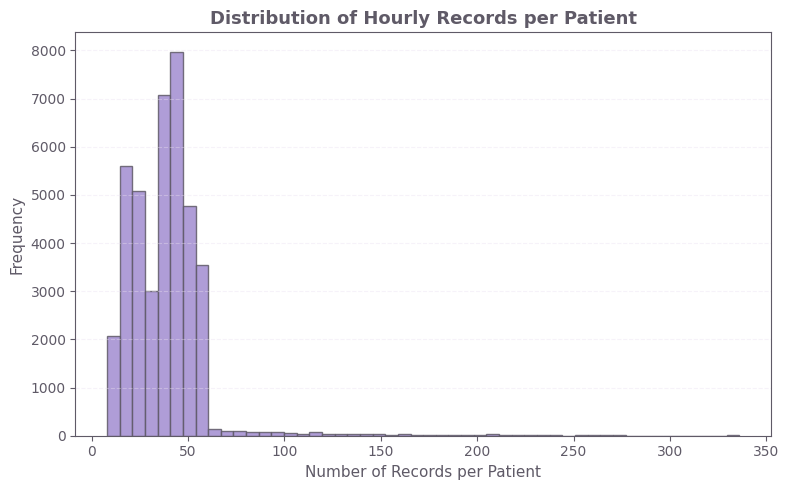

In [45]:
records_per_patient = df.groupby("Patient_ID").size()

plt.figure(figsize=(8, 5))
plt.hist(
    records_per_patient,
    bins=50,
    color=PALETTE["primary"],
    edgecolor=PALETTE["dark"],
    alpha=0.85
)

plt.title("Distribution of Hourly Records per Patient")
plt.xlabel("Number of Records per Patient")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

Patients contribute multiple hourly observations rather than a single row. This confirms the importance of splitting the data by Patient_ID instead of random row sampling, so that leakage is avoided.

### Age distribution by sepsis label

C:\Users\user\AppData\Local\Temp\ipykernel_22628\2268670913.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


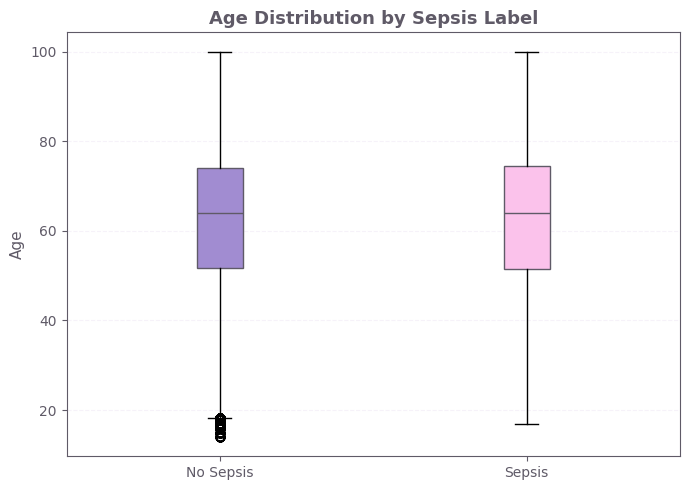

In [46]:
age_no_sepsis = df.loc[df["SepsisLabel"] == 0, "Age"].dropna()
age_sepsis = df.loc[df["SepsisLabel"] == 1, "Age"].dropna()

plt.figure(figsize=(7, 5))
bp = plt.boxplot(
    [age_no_sepsis, age_sepsis],
    labels=["No Sepsis", "Sepsis"],
    patch_artist=True
)

for patch, color in zip(bp["boxes"], [PALETTE["primary"], PALETTE["secondary"]]):
    patch.set_facecolor(color)
    patch.set_edgecolor(PALETTE["dark"])

for median in bp["medians"]:
    median.set_color(PALETTE["dark"])

plt.title("Age Distribution by Sepsis Label")
plt.ylabel("Age")
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

This plot provides a simple view of how age is distributed across the two classes. Age was retained as a final feature because it is complete and clinically relevant.

### Gender distribution by sepsis label

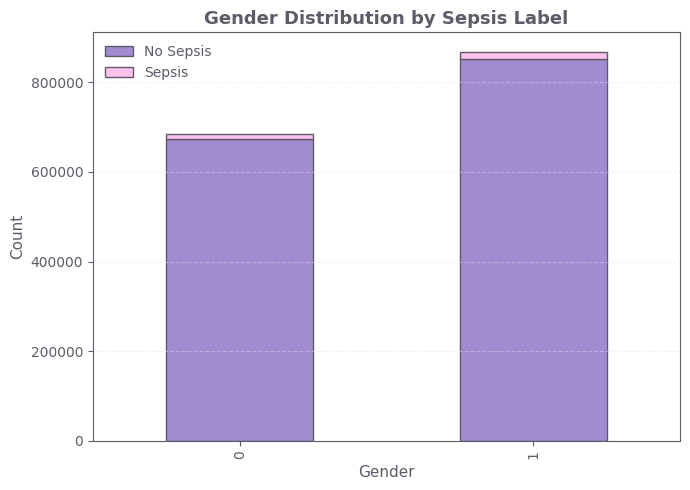

In [47]:
gender_target = pd.crosstab(df["Gender"], df["SepsisLabel"])

gender_target.plot(
    kind="bar",
    stacked=True,
    figsize=(7, 5),
    color=[PALETTE["primary"], PALETTE["secondary"]],
    edgecolor=PALETTE["dark"]
)

plt.title("Gender Distribution by Sepsis Label")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(["No Sepsis", "Sepsis"])
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

Gender is included in the dataset and is used later as the protected characteristic for fairness evaluation. This chart shows how the target classes are distributed across the two gender groups.

### Key vital signs by sepsis label

C:\Users\user\AppData\Local\Temp\ipykernel_22628\1027307262.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
C:\Users\user\AppData\Local\Temp\ipykernel_22628\1027307262.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
C:\Users\user\AppData\Local\Temp\ipykernel_22628\1027307262.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
C:\Users\user\AppData\Local\Temp\ipykernel_22628\1027307262.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be d

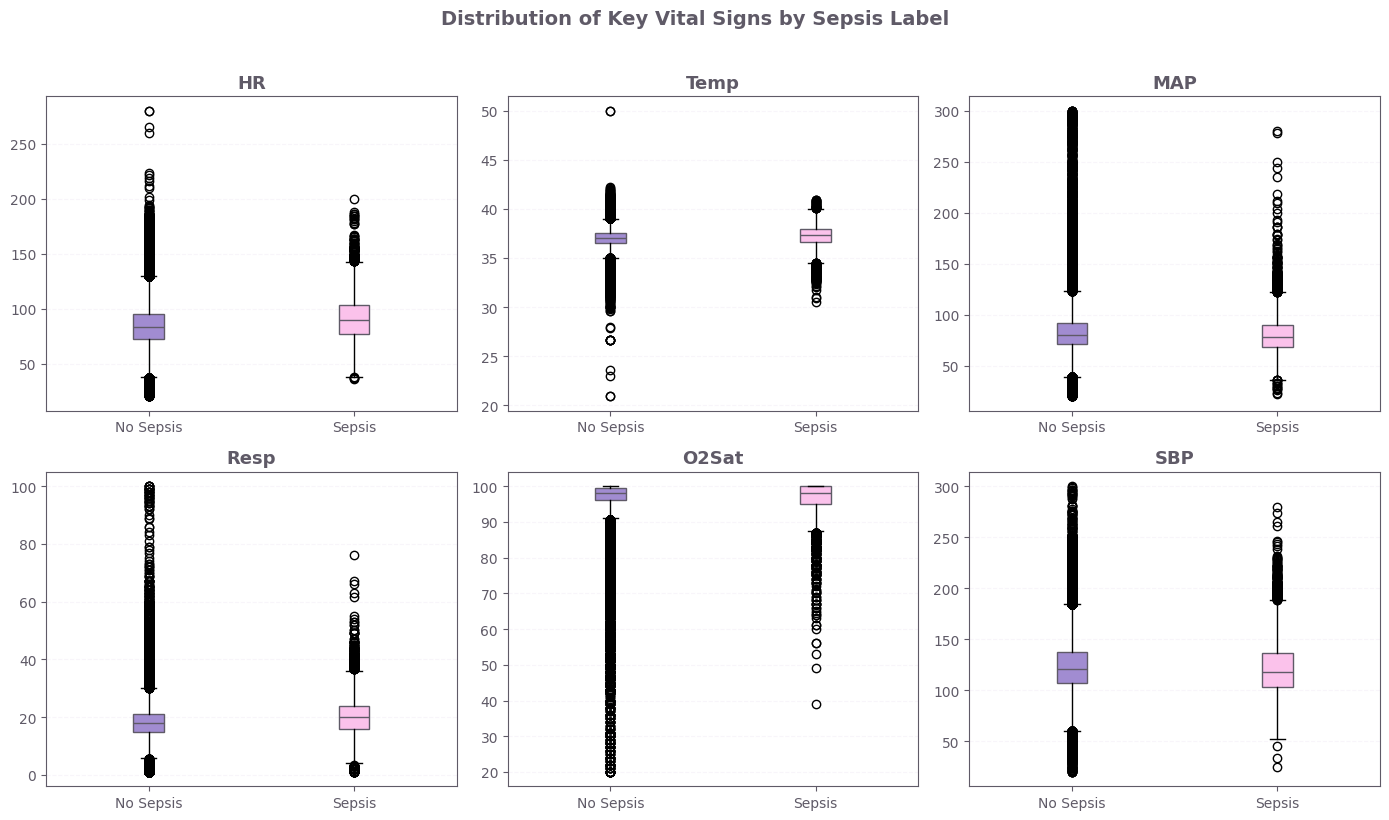

In [48]:
selected_features = ["HR", "Temp", "MAP", "Resp", "O2Sat", "SBP"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feature in enumerate(selected_features):
    data_no = df.loc[df["SepsisLabel"] == 0, feature].dropna()
    data_yes = df.loc[df["SepsisLabel"] == 1, feature].dropna()

    bp = axes[i].boxplot(
        [data_no, data_yes],
        labels=["No Sepsis", "Sepsis"],
        patch_artist=True
    )

    for patch, color in zip(bp["boxes"], [PALETTE["primary"], PALETTE["secondary"]]):
        patch.set_facecolor(color)
        patch.set_edgecolor(PALETTE["dark"])

    for median in bp["medians"]:
        median.set_color(PALETTE["dark"])

    axes[i].set_title(feature)
    axes[i].grid(axis="y", alpha=0.3)

plt.suptitle("Distribution of Key Vital Signs by Sepsis Label", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

These boxplots show how several core physiological variables vary across the sepsis and non-sepsis groups. This helps provide clinical context for the final feature set and shows that some separation exists between the classes.

### Correlation heatmap of final model features

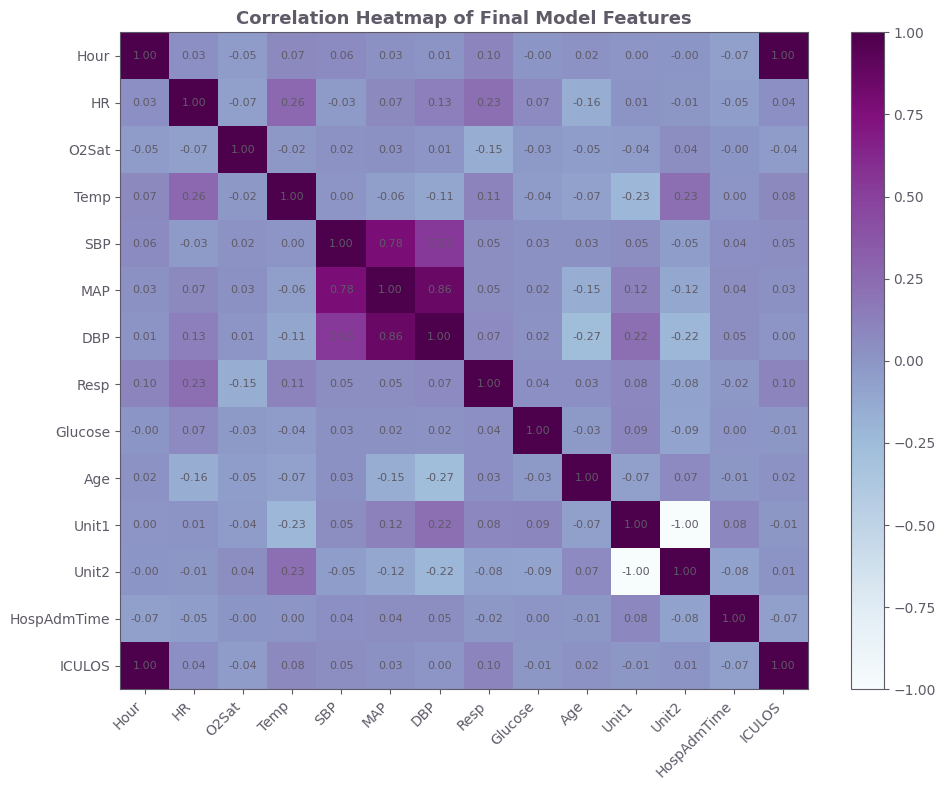

In [49]:
final_features = [
    "Hour", "HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp",
    "Glucose", "Age", "Unit1", "Unit2", "HospAdmTime", "ICULOS"
]

corr_sample = df[final_features].sample(min(50000, len(df)), random_state=42)
corr_matrix = corr_sample.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap="BuPu", aspect="auto")

ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8, color=PALETTE["dark"])

plt.title("Correlation Heatmap of Final Model Features")
plt.colorbar(im)
plt.tight_layout()
plt.show()

The correlation heatmap helps show how the final retained predictors relate to one another. This is useful for understanding whether some variables carry overlapping information before model training.

### ICU length of stay by sepsis label

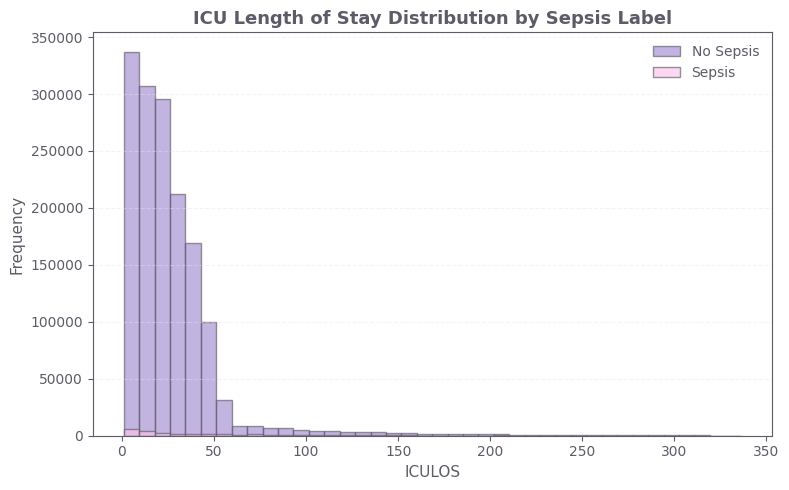

In [50]:
iculos_no = df.loc[df["SepsisLabel"] == 0, "ICULOS"].dropna()
iculos_yes = df.loc[df["SepsisLabel"] == 1, "ICULOS"].dropna()

plt.figure(figsize=(8, 5))
plt.hist(
    iculos_no,
    bins=40,
    alpha=0.65,
    label="No Sepsis",
    color=PALETTE["primary"],
    edgecolor=PALETTE["dark"]
)
plt.hist(
    iculos_yes,
    bins=40,
    alpha=0.65,
    label="Sepsis",
    color=PALETTE["secondary"],
    edgecolor=PALETTE["dark"]
)

plt.title("ICU Length of Stay Distribution by Sepsis Label")
plt.xlabel("ICULOS")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

ICULOS appears repeatedly later in the model explanations, so this distribution is useful for understanding how ICU stay length differs between the two classes even before modelling.

## Class Imbalance and Missingness

In [51]:

# Class distribution
class_counts = df["SepsisLabel"].value_counts().sort_index()
print("Class Distribution: ",class_counts)

# Missingness overview
missing_pct = df.isnull().mean() * 100
print("Top 20 columns by missingness:")
print(missing_pct.sort_values(ascending=False).head(20))

Class Distribution:  SepsisLabel
0    1524294
1      27916
Name: count, dtype: int64
Top 20 columns by missingness:
Bilirubin_direct    99.807371
Fibrinogen          99.340167
TroponinI           99.047745
Bilirubin_total     98.509158
Alkalinephos        98.393194
AST                 98.377604
Lactate             97.329872
PTT                 97.055875
SaO2                96.549372
EtCO2               96.286843
Phosphate           95.986303
HCO3                95.810618
Chloride            95.460279
BaseExcess          94.579020
PaCO2               94.440121
Calcium             94.116067
Platelets           94.059502
Creatinine          93.904433
Magnesium           93.689578
WBC                 93.593199
dtype: float64


The target variable is highly imbalanced, with non-sepsis cases far outnumbering sepsis-positive cases.  
This is important because accuracy alone can look strong even when the model misses many true sepsis cases.

## Feature Filtering and Preprocessing Decisions

In [52]:

# Start from original dataframe
df4 = df.copy()

# Drop non-informative index-like column if present
if "Unnamed: 0" in df4.columns:
    df4 = df4.drop(columns=["Unnamed: 0"])

# Remove features with >92% missingness
missing_pct = df4.isnull().mean() * 100
high_missing_cols_92 = missing_pct[missing_pct > 92].index.tolist()

protected_cols = ["SepsisLabel", "Gender", "Patient_ID"]
high_missing_cols_92 = [col for col in high_missing_cols_92 if col not in protected_cols]

print("Columns with >92% missing:")
print(high_missing_cols_92)

df4 = df4.drop(columns=high_missing_cols_92)

# Final retained set before last sparse cleanup
print("\nRemaining columns after >92% filter:")
print(df4.columns.tolist())

print("\nMissing percentage after >92% filter:")
print((df4.isnull().mean() * 100).sort_values(ascending=False))

Columns with >92% missing:
['EtCO2', 'BaseExcess', 'HCO3', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Lactate', 'Magnesium', 'Phosphate', 'Bilirubin_total', 'TroponinI', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets']

Remaining columns after >92% filter:
['Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'FiO2', 'Glucose', 'Potassium', 'Hct', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']

Missing percentage after >92% filter:
FiO2           91.665754
Hct            91.145979
Potassium      90.689082
Glucose        82.894325
Temp           66.162697
Unit1          39.425078
Unit2          39.425078
DBP            31.345887
Resp           15.354559
SBP            14.576958
O2Sat          13.061119
MAP            12.451279
HR              9.882619
HospAdmTime     0.000515
Hour            0.000000
Gender          0.000000
Age             0.000000
ICULOS          0.00000

A 92% missingness threshold was used because stricter filtering removed too many useful variables, while looser filtering kept too many near-empty features.  
After this step, three additional ultra-sparse variables were removed manually.

In [53]:

# Final feature columns after removing three ultra-sparse variables
final_features = [
    "Hour", "HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp",
    "Glucose", "Age", "Unit1", "Unit2", "HospAdmTime", "ICULOS"
]

target = "SepsisLabel"
protected_attr = "Gender"

# Keep only required columns plus target/protected/id
data = df4[final_features + [target, protected_attr, "Patient_ID"]].copy()

print("Final modelling dataframe shape:", data.shape)
print("Unique patients:", data["Patient_ID"].nunique())

Final modelling dataframe shape: (1552210, 17)
Unique patients: 40336


In [54]:

# Missingness in retained features
missing_pct_final = (data[final_features].isnull().mean() * 100).sort_values(ascending=True)

print("Missing percentage in final features:")
print(missing_pct_final)

Missing percentage in final features:
Hour            0.000000
Age             0.000000
ICULOS          0.000000
HospAdmTime     0.000515
HR              9.882619
MAP            12.451279
O2Sat          13.061119
SBP            14.576958
Resp           15.354559
DBP            31.345887
Unit2          39.425078
Unit1          39.425078
Temp           66.162697
Glucose        82.894325
dtype: float64


## Train-Test Split by Patient_ID

In [55]:

patient_ids = data["Patient_ID"].unique()

train_ids, test_ids = train_test_split(
    patient_ids,
    test_size=0.2,
    random_state=42
)

train_df = data[data["Patient_ID"].isin(train_ids)].copy()
test_df = data[data["Patient_ID"].isin(test_ids)].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train unique patients:", train_df["Patient_ID"].nunique())
print("Test unique patients:", test_df["Patient_ID"].nunique())

overlap = set(train_df["Patient_ID"]).intersection(set(test_df["Patient_ID"]))
print("Patient overlap:", len(overlap))

print("\nTrain SepsisLabel distribution:")
print(train_df["SepsisLabel"].value_counts(normalize=True))
print("\nTest SepsisLabel distribution:")
print(test_df["SepsisLabel"].value_counts(normalize=True))

print("\nTrain Gender distribution:")
print(train_df["Gender"].value_counts(normalize=True))
print("\nTest Gender distribution:")
print(test_df["Gender"].value_counts(normalize=True))

Train shape: (1242217, 17)
Test shape: (309993, 17)
Train unique patients: 32268
Test unique patients: 8068
Patient overlap: 0

Train SepsisLabel distribution:
SepsisLabel
0    0.982254
1    0.017746
Name: proportion, dtype: float64

Test SepsisLabel distribution:
SepsisLabel
0    0.981058
1    0.018942
Name: proportion, dtype: float64

Train Gender distribution:
Gender
1    0.555948
0    0.444052
Name: proportion, dtype: float64

Test Gender distribution:
Gender
1    0.572577
0    0.427423
Name: proportion, dtype: float64


The split is done by **Patient_ID** to prevent leakage.  
This matters because the same patient appears in multiple hourly rows, so random row-based splitting would make the evaluation unrealistically optimistic.

## Prepare Features and Apply Imputation

In [56]:

X_train = train_df[final_features].copy()
y_train = train_df[target].copy()

X_test = test_df[final_features].copy()
y_test = test_df[target].copy()

gender_test = test_df[protected_attr].copy()

imputer = SimpleImputer(strategy="median")

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("NaNs in X_train_imputed:", X_train_imputed.isnull().sum().sum())
print("NaNs in X_test_imputed:", X_test_imputed.isnull().sum().sum())

NaNs in X_train_imputed: 0
NaNs in X_test_imputed: 0


Gender is excluded from the predictive features and kept only for fairness evaluation.  
This makes the subgroup analysis easier to interpret.

## Baseline Model: Random Forest

In [57]:

baseline_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

baseline_model.fit(X_train, y_train)

y_pred_rf = baseline_model.predict(X_test)
y_prob_rf = baseline_model.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
pr_auc_rf = average_precision_score(y_test, y_prob_rf)

print("Random Forest Results")
print("Accuracy:", acc_rf)
print("Precision:", prec_rf)
print("Recall:", rec_rf)
print("F1-score:", f1_rf)
print("ROC-AUC:", roc_auc_rf)
print("PR-AUC:", pr_auc_rf)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.9805769807705336
Precision: 0.06432748538011696
Recall: 0.0018732970027247955
F1-score: 0.0036405758729108058
ROC-AUC: 0.711728535139467
PR-AUC: 0.06077892567781577

Confusion Matrix:
[[303961    160]
 [  5861     11]]


The Random Forest baseline achieved high accuracy but poor positive-class recall, which showed that a stronger model was needed for meaningful sepsis detection.

## Interpretation and Reason for Switching to XGBoost

The Random Forest model was used first as a baseline to understand how the dataset behaved under a standard classification approach. Even though the model produced high overall accuracy, the results showed that it was not identifying the positive sepsis class effectively. In particular, the recall for class 1 was extremely low, which means that the model missed most of the true sepsis cases. This was a serious limitation because, in a sepsis prediction task, the ability to detect true positive cases is more important than simply achieving high accuracy on the majority class. A model that predicts mostly non-sepsis cases may appear strong overall, but it is not clinically useful if it fails to recognise genuine deterioration.

Because of this, the modelling approach was changed to XGBoost. XGBoost was chosen because it is generally more effective for structured tabular data, can capture nonlinear relationships more strongly, and provides better support for handling imbalanced datasets through parameters such as `scale_pos_weight`. The move to XGBoost was therefore made to improve class 1 detection and to build a model that was more suitable for both performance evaluation and fairness analysis.

## XGBoost Baseline

In [58]:

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print("Negative class count:", neg_count)
print("Positive class count:", pos_count)
print("scale_pos_weight:", scale_pos_weight)

xgb_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb, zero_division=0)
rec_xgb = recall_score(y_test, y_pred_xgb, zero_division=0)
f1_xgb = f1_score(y_test, y_pred_xgb, zero_division=0)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)
pr_auc_xgb = average_precision_score(y_test, y_prob_xgb)

print("XGBoost Baseline Results")
print("Accuracy:", acc_xgb)
print("Precision:", prec_xgb)
print("Recall:", rec_xgb)
print("F1-score:", f1_xgb)
print("ROC-AUC:", roc_auc_xgb)
print("PR-AUC:", pr_auc_xgb)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

Negative class count: 1220173
Positive class count: 22044
scale_pos_weight: 55.351705679549994
XGBoost Baseline Results
Accuracy: 0.8129990032032981
Precision: 0.0592992369770078
Recall: 0.596900544959128
F1-score: 0.10788100771018329
ROC-AUC: 0.7761788052716219
PR-AUC: 0.09205696442683181

Confusion Matrix:
[[248519  55602]
 [  2367   3505]]


## Hyperparameter Tuning for XGBoost

In [59]:

# Patient-based subset for tuning
tune_patient_ids = train_df["Patient_ID"].unique()
tune_ids, _ = train_test_split(
    tune_patient_ids,
    test_size=0.75,
    random_state=42
)

tune_df = train_df[train_df["Patient_ID"].isin(tune_ids)].copy()

X_tune = tune_df[final_features].copy()
y_tune = tune_df[target].copy()

xgb_tune_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ))
])

param_distributions = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [3, 5, 7],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__min_child_weight": [1, 3, 5],
    "classifier__subsample": [0.7, 0.8, 0.9],
    "classifier__colsample_bytree": [0.7, 0.8, 0.9]
}

random_search = RandomizedSearchCV(
    estimator=xgb_tune_pipeline,
    param_distributions=param_distributions,
    n_iter=12,
    scoring="f1",
    cv=3,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_tune, y_tune)

print("Best CV score:", random_search.best_score_)
print("Best params:")
print(random_search.best_params_)

Best CV score: 0.09767856911182952
Best params:
{'classifier__subsample': 0.7, 'classifier__n_estimators': 100, 'classifier__min_child_weight': 5, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.03, 'classifier__colsample_bytree': 0.7}


## Final Selected Model: Tuned XGBoost

In [60]:

tuned_xgb_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", XGBClassifier(
        n_estimators=100,
        max_depth=7,
        learning_rate=0.03,
        min_child_weight=5,
        subsample=0.7,
        colsample_bytree=0.7,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ))
])

tuned_xgb_model.fit(X_train, y_train)

y_pred_tuned_xgb = tuned_xgb_model.predict(X_test)
y_prob_tuned_xgb = tuned_xgb_model.predict_proba(X_test)[:, 1]

acc_tuned = accuracy_score(y_test, y_pred_tuned_xgb)
prec_tuned = precision_score(y_test, y_pred_tuned_xgb, zero_division=0)
rec_tuned = recall_score(y_test, y_pred_tuned_xgb, zero_division=0)
f1_tuned = f1_score(y_test, y_pred_tuned_xgb, zero_division=0)
roc_auc_tuned = roc_auc_score(y_test, y_prob_tuned_xgb)
pr_auc_tuned = average_precision_score(y_test, y_prob_tuned_xgb)

print("Tuned XGBoost Results")
print("Accuracy:", acc_tuned)
print("Precision:", prec_tuned)
print("Recall:", rec_tuned)
print("F1-score:", f1_tuned)
print("ROC-AUC:", roc_auc_tuned)
print("PR-AUC:", pr_auc_tuned)

cm_tuned = confusion_matrix(y_test, y_pred_tuned_xgb)
print("\nConfusion Matrix:")
print(cm_tuned)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned_xgb, zero_division=0))

Tuned XGBoost Results
Accuracy: 0.8263928540321879
Precision: 0.06146528857587122
Recall: 0.5722070844686649
F1-score: 0.11100649189751723
ROC-AUC: 0.7762999922356302
PR-AUC: 0.09261411578570439

Confusion Matrix:
[[252816  51305]
 [  2512   3360]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.83      0.90    304121
           1       0.06      0.57      0.11      5872

    accuracy                           0.83    309993
   macro avg       0.53      0.70      0.51    309993
weighted avg       0.97      0.83      0.89    309993



This tuned XGBoost model is the final selected model because it gives the best overall balance for sepsis detection without the drawbacks seen in the SMOTE experiment later on.

## Fairness Evaluation for Final Tuned XGBoost

In [61]:

def fairness_metrics_by_group(y_true, y_pred, group):
    rows = []

    for g in sorted(group.dropna().unique()):
        mask = (group == g)
        y_true_g = y_true[mask]
        y_pred_g = y_pred[mask]

        acc = accuracy_score(y_true_g, y_pred_g)
        pred_positive_rate = np.mean(y_pred_g == 1)

        cm = confusion_matrix(y_true_g, y_pred_g, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0

        rows.append({
            "Gender": g,
            "Accuracy": acc,
            "Demographic_Parity": pred_positive_rate,
            "Equal_Opportunity_TPR": tpr,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp
        })

    return pd.DataFrame(rows)

fairness_df_tuned = fairness_metrics_by_group(
    y_test.reset_index(drop=True),
    pd.Series(y_pred_tuned_xgb),
    gender_test.reset_index(drop=True)
)

accuracy_gap = abs(fairness_df_tuned.loc[0, "Accuracy"] - fairness_df_tuned.loc[1, "Accuracy"])
dp_gap = abs(fairness_df_tuned.loc[0, "Demographic_Parity"] - fairness_df_tuned.loc[1, "Demographic_Parity"])
eo_gap = abs(fairness_df_tuned.loc[0, "Equal_Opportunity_TPR"] - fairness_df_tuned.loc[1, "Equal_Opportunity_TPR"])

print("Fairness metrics by Gender for Tuned XGBoost:")
print(fairness_df_tuned)

print("\nFairness Gaps:")
print("Equal Accuracy Gap:", accuracy_gap)
print("Demographic Parity Gap:", dp_gap)
print("Equal Opportunity Gap:", eo_gap)

Fairness metrics by Gender for Tuned XGBoost:
   Gender  Accuracy  Demographic_Parity  Equal_Opportunity_TPR      TN     FP  \
0       0  0.826201            0.175693               0.552401  108147  21956   
1       1  0.826536            0.176828               0.585850  144669  29349   

     FN    TP  
0  1072  1323  
1  1440  2037  

Fairness Gaps:
Equal Accuracy Gap: 0.0003348085533608769
Demographic Parity Gap: 0.0011342982572259963
Equal Opportunity Gap: 0.033449035505015656


The final model shows very small gaps under equal accuracy and demographic parity, while a modest gap remains under equal opportunity.  
This means the model is broadly balanced overall, but one gender group is still slightly less likely to have true sepsis cases correctly detected.

## Experiment using XGBoost with SMOTE

In [62]:
# Cross-validation with SMOTE inside a for loop
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_imputed, y_train), start=1):
    X_fold_train = X_train_imputed.iloc[train_idx].copy()
    y_fold_train = y_train.iloc[train_idx].copy()
    X_fold_val = X_train_imputed.iloc[val_idx].copy()
    y_fold_val = y_train.iloc[val_idx].copy()

    smote = SMOTE(random_state=42)
    X_fold_train_resampled, y_fold_train_resampled = smote.fit_resample(X_fold_train, y_fold_train)

    model = XGBClassifier(
        n_estimators=100,
        max_depth=7,
        learning_rate=0.03,
        min_child_weight=5,
        subsample=0.7,
        colsample_bytree=0.7,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_fold_train_resampled, y_fold_train_resampled)
    y_val_pred = model.predict(X_fold_val)
    y_val_prob = model.predict_proba(X_fold_val)[:, 1]

    cv_results.append({
        "Fold": fold,
        "Accuracy": accuracy_score(y_fold_val, y_val_pred),
        "Precision": precision_score(y_fold_val, y_val_pred, zero_division=0),
        "Recall": recall_score(y_fold_val, y_val_pred, zero_division=0),
        "F1-score": f1_score(y_fold_val, y_val_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_fold_val, y_val_prob),
        "PR-AUC": average_precision_score(y_fold_val, y_val_prob),
    })

cv_results_df = pd.DataFrame(cv_results)
print("Cross-validation results with SMOTE:")
print(cv_results_df)
print("\nAverage CV results:")
print(cv_results_df.mean(numeric_only=True))

# Final SMOTE model
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_imputed, y_train)

final_xgb_smote = XGBClassifier(
    n_estimators=100,
    max_depth=7,
    learning_rate=0.03,
    min_child_weight=5,
    subsample=0.7,
    colsample_bytree=0.7,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

final_xgb_smote.fit(X_train_resampled, y_train_resampled)

y_pred_smote = final_xgb_smote.predict(X_test_imputed)
y_prob_smote = final_xgb_smote.predict_proba(X_test_imputed)[:, 1]

acc_smote = accuracy_score(y_test, y_pred_smote)
prec_smote = precision_score(y_test, y_pred_smote, zero_division=0)
rec_smote = recall_score(y_test, y_pred_smote, zero_division=0)
f1_smote = f1_score(y_test, y_pred_smote, zero_division=0)
roc_auc_smote = roc_auc_score(y_test, y_prob_smote)
pr_auc_smote = average_precision_score(y_test, y_prob_smote)

print("\nFinal XGBoost + SMOTE Results")
print("Accuracy:", acc_smote)
print("Precision:", prec_smote)
print("Recall:", rec_smote)
print("F1-score:", f1_smote)
print("ROC-AUC:", roc_auc_smote)
print("PR-AUC:", pr_auc_smote)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))

Cross-validation results with SMOTE:
   Fold  Accuracy  Precision    Recall  F1-score   ROC-AUC    PR-AUC
0     1  0.926688   0.100665  0.394647  0.160413  0.771019  0.088202
1     2  0.928688   0.103740  0.395101  0.164332  0.770089  0.086868
2     3  0.927887   0.101346  0.389519  0.160843  0.774330  0.087880
3     4  0.931546   0.102135  0.366750  0.159775  0.768326  0.083023
4     5  0.926623   0.099971  0.391699  0.159288  0.772856  0.083231

Average CV results:
Fold         3.000000
Accuracy     0.928286
Precision    0.101571
Recall       0.387543
F1-score     0.160930
ROC-AUC      0.771324
PR-AUC       0.085841
dtype: float64

Final XGBoost + SMOTE Results
Accuracy: 0.9279532118467191
Precision: 0.1011339406861795
Recall: 0.35541553133514986
F1-score: 0.15746189829485438
ROC-AUC: 0.7516675601866556
PR-AUC: 0.08026155214932058

Confusion Matrix:
[[285572  18549]
 [  3785   2087]]


This SMOTE-based version is kept as an additional comparison experiment.  
Although it improves accuracy, precision, and F1-score, it reduces recall, ROC-AUC, and PR-AUC, so it is **not** selected as the final model.

## Fairness Evaluation for XGBoost + SMOTE


In [63]:

fairness_df_smote = fairness_metrics_by_group(
    y_test.reset_index(drop=True),
    pd.Series(y_pred_smote),
    gender_test.reset_index(drop=True)
)

accuracy_gap_smote = abs(fairness_df_smote.loc[0, "Accuracy"] - fairness_df_smote.loc[1, "Accuracy"])
dp_gap_smote = abs(fairness_df_smote.loc[0, "Demographic_Parity"] - fairness_df_smote.loc[1, "Demographic_Parity"])
eo_gap_smote = abs(fairness_df_smote.loc[0, "Equal_Opportunity_TPR"] - fairness_df_smote.loc[1, "Equal_Opportunity_TPR"])

print("Fairness metrics by Gender for XGBoost + SMOTE:")
print(fairness_df_smote)

print("\nFairness Gaps for XGBoost + SMOTE:")
print("Equal Accuracy Gap:", accuracy_gap_smote)
print("Demographic Parity Gap:", dp_gap_smote)
print("Equal Opportunity Gap:", eo_gap_smote)

Fairness metrics by Gender for XGBoost + SMOTE:
   Gender  Accuracy  Demographic_Parity  Equal_Opportunity_TPR      TN     FP  \
0       0  0.934180            0.060152               0.343215  122955   7148   
1       1  0.923305            0.071360               0.363819  162617  11401   

     FN    TP  
0  1573   822  
1  2212  1265  

Fairness Gaps for XGBoost + SMOTE:
Equal Accuracy Gap: 0.010875256740472183
Demographic Parity Gap: 0.011207905264162737
Equal Opportunity Gap: 0.02060435321165094


The SMOTE model slightly reduces the equal opportunity gap, but it increases the gaps in equal accuracy and demographic parity and weakens the overall class 1 detection performance.  
For that reason, the earlier tuned XGBoost model remains the final selected model.

## Model Evaluation and Comparison

This section presents the evaluation of the final tuned XGBoost model and compares it with the additional XGBoost + SMOTE experiment. The comparison includes predictive performance, fairness outcomes, and local explainability.

### Confusion matrix for final tuned XGBoost

<Figure size 600x500 with 0 Axes>

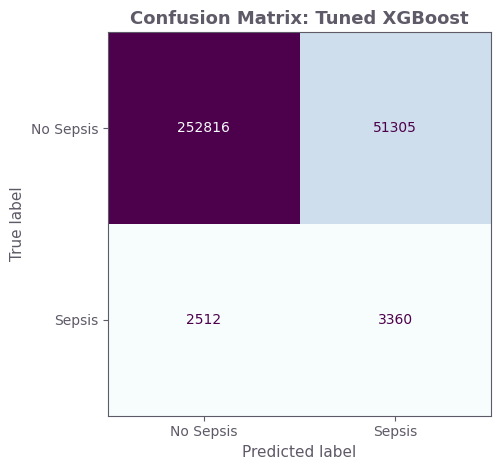

In [64]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tuned_xgb,
    display_labels=["No Sepsis", "Sepsis"],
    cmap="BuPu",
    colorbar=False
)

plt.title("Confusion Matrix: Tuned XGBoost", color=PALETTE["dark"])
plt.tight_layout()
plt.show()

The tuned XGBoost model shows a much better balance between identifying positive sepsis cases and controlling false alarms than the earlier baseline model. Although false positives remain substantial, the model captures a meaningful number of true sepsis cases, which is important in a high-risk clinical setting.

### Confusion matrix for XGBoost + SMOTE

<Figure size 600x500 with 0 Axes>

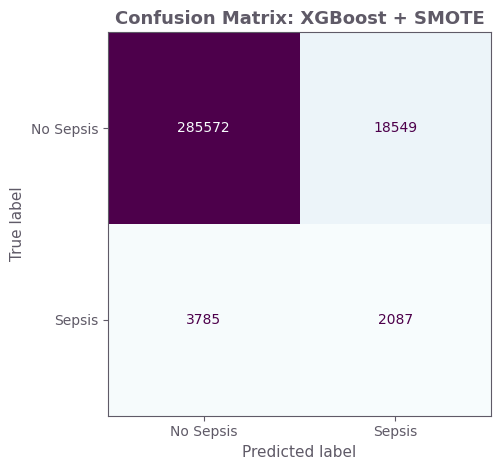

In [65]:
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_smote,
    display_labels=["No Sepsis", "Sepsis"],
    cmap="BuPu",
    colorbar=False
)

plt.title("Confusion Matrix: XGBoost + SMOTE", color=PALETTE["dark"])
plt.tight_layout()
plt.show()

The SMOTE-based model improved some overall metrics such as accuracy and F1-score, but it reduced recall compared with the tuned XGBoost model. This means fewer true sepsis cases were identified, which limited its value as the final model despite the apparent gains in some summary metrics.

### ROC curve comparison

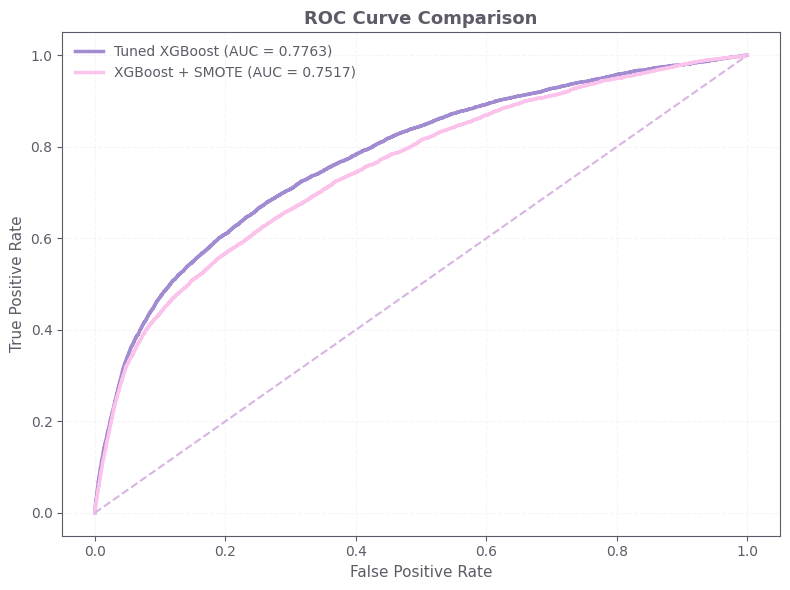

In [66]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_prob_tuned_xgb)
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_prob_smote)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr_tuned,
    tpr_tuned,
    color=PALETTE["primary"],
    linewidth=2.5,
    label=f"Tuned XGBoost (AUC = {roc_auc_tuned:.4f})"
)
plt.plot(
    fpr_smote,
    tpr_smote,
    color=PALETTE["secondary"],
    linewidth=2.5,
    label=f"XGBoost + SMOTE (AUC = {roc_auc_smote:.4f})"
)
plt.plot([0, 1], [0, 1], linestyle="--", color=PALETTE["mid"], linewidth=1.5)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.grid(alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

The ROC curve comparison shows that the tuned XGBoost model achieved slightly stronger ranking performance than the SMOTE-based version. This supports the earlier metric results, where tuned XGBoost produced the better ROC-AUC score overall.

### Precision-Recall curve comparison

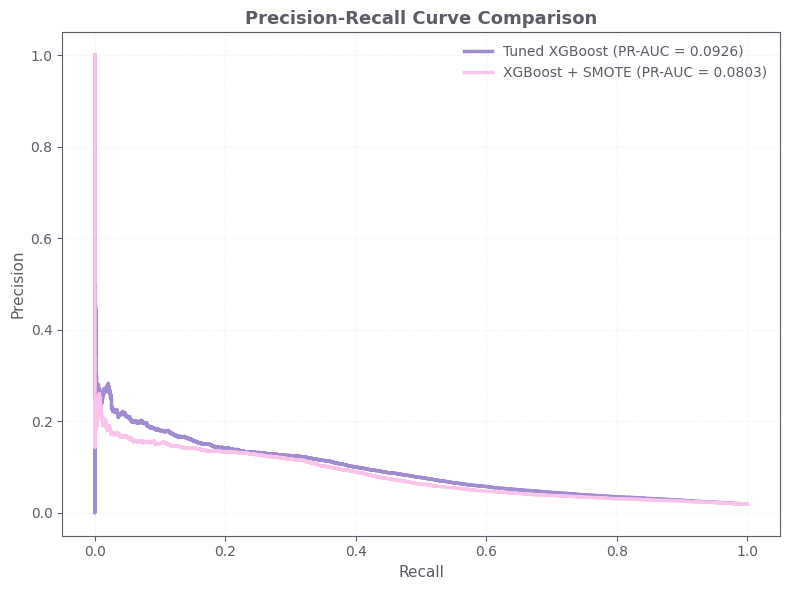

In [67]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision_tuned_curve, recall_tuned_curve, _ = precision_recall_curve(y_test, y_prob_tuned_xgb)
precision_smote_curve, recall_smote_curve, _ = precision_recall_curve(y_test, y_prob_smote)

plt.figure(figsize=(8, 6))
plt.plot(
    recall_tuned_curve,
    precision_tuned_curve,
    color=PALETTE["primary"],
    linewidth=2.5,
    label=f"Tuned XGBoost (PR-AUC = {pr_auc_tuned:.4f})"
)
plt.plot(
    recall_smote_curve,
    precision_smote_curve,
    color=PALETTE["secondary"],
    linewidth=2.5,
    label=f"XGBoost + SMOTE (PR-AUC = {pr_auc_smote:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.grid(alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

The precision-recall curve is more informative than ROC in this case because sepsis is a rare class. The tuned XGBoost model achieved the stronger PR-AUC score, which supports its selection as the final model.

### Performance comparison table

In [68]:
performance_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"],
    "Tuned XGBoost": [acc_tuned, prec_tuned, rec_tuned, f1_tuned, roc_auc_tuned, pr_auc_tuned],
    "XGBoost + SMOTE": [acc_smote, prec_smote, rec_smote, f1_smote, roc_auc_smote, pr_auc_smote]
})

performance_comparison = performance_comparison.round(4)
print("Performance Comparison Table")
performance_comparison

Performance Comparison Table


,Metric,Tuned XGBoost,XGBoost + SMOTE
0,Accuracy,0.8264,0.9280
1,Precision,0.0615,0.1011
2,Recall,0.5722,0.3554
3,F1-score,0.1110,0.1575
4,ROC-AUC,0.7763,0.7517
5,PR-AUC,0.0926,0.0803


The table shows that the SMOTE-based model improved accuracy, precision, and F1-score, but the tuned XGBoost model retained better recall, ROC-AUC, and PR-AUC. In a sepsis prediction setting, these latter measures are especially important because the model should remain sensitive to genuine positive cases.

### Performance comparison dumbbell chart

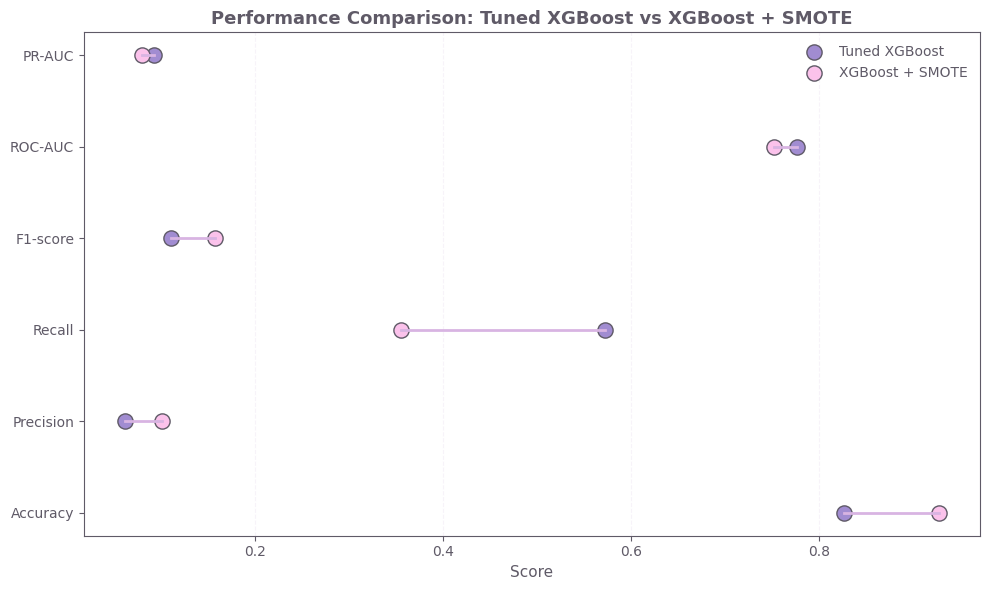

In [69]:
import matplotlib.pyplot as plt
import numpy as np

df_perf = performance_comparison.copy()
y_pos = np.arange(len(df_perf))

plt.figure(figsize=(10, 6))

for i in range(len(df_perf)):
    plt.plot(
        [df_perf.loc[i, "Tuned XGBoost"], df_perf.loc[i, "XGBoost + SMOTE"]],
        [i, i],
        color=PALETTE["mid"],
        linewidth=2
    )

plt.scatter(
    df_perf["Tuned XGBoost"],
    y_pos,
    s=120,
    color=PALETTE["primary"],
    edgecolors=PALETTE["dark"],
    label="Tuned XGBoost"
)

plt.scatter(
    df_perf["XGBoost + SMOTE"],
    y_pos,
    s=120,
    color=PALETTE["secondary"],
    edgecolors=PALETTE["dark"],
    label="XGBoost + SMOTE"
)

plt.yticks(y_pos, df_perf["Metric"])
plt.xlabel("Score")
plt.title("Performance Comparison: Tuned XGBoost vs XGBoost + SMOTE")
plt.grid(axis="x", alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

This visual comparison makes the trade-off clearer. The SMOTE-based model improves some high-level metrics, but the tuned XGBoost model remains stronger in recall and ranking performance, which is more suitable for this healthcare task.

### Fairness gap comparison table

In [70]:
fairness_gap_comparison = pd.DataFrame({
    "Fairness Metric": [
        "Equal Accuracy Gap",
        "Demographic Parity Gap",
        "Equal Opportunity Gap"
    ],
    "Tuned XGBoost": [
        accuracy_gap,
        dp_gap,
        eo_gap
    ],
    "XGBoost + SMOTE": [
        accuracy_gap_smote,
        dp_gap_smote,
        eo_gap_smote
    ]
})

fairness_gap_comparison = fairness_gap_comparison.round(4)
print("Fairness Gap Comparison Table")
fairness_gap_comparison

Fairness Gap Comparison Table


,Fairness Metric,Tuned XGBoost,XGBoost + SMOTE
0,Equal Accuracy Gap,0.0003,0.0109
1,Demographic Parity Gap,0.0011,0.0112
2,Equal Opportunity Gap,0.0334,0.0206


The fairness gap table shows that the SMOTE-based model reduced the equal opportunity gap, but it increased the gaps for equal accuracy and demographic parity. This creates a mixed fairness picture rather than a clear overall improvement.

### Fairness gap lollipop chart

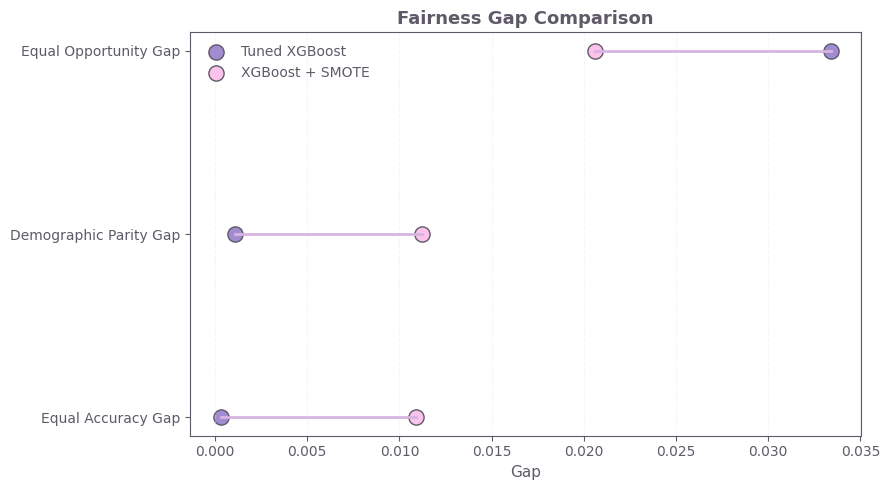

In [71]:
df_gap = fairness_gap_comparison.copy()
y_pos = np.arange(len(df_gap))

plt.figure(figsize=(9, 5))

for i in range(len(df_gap)):
    plt.plot(
        [df_gap.loc[i, "Tuned XGBoost"], df_gap.loc[i, "XGBoost + SMOTE"]],
        [i, i],
        color=PALETTE["mid"],
        linewidth=2
    )

plt.scatter(
    df_gap["Tuned XGBoost"],
    y_pos,
    s=120,
    color=PALETTE["primary"],
    edgecolors=PALETTE["dark"],
    label="Tuned XGBoost"
)

plt.scatter(
    df_gap["XGBoost + SMOTE"],
    y_pos,
    s=120,
    color=PALETTE["secondary"],
    edgecolors=PALETTE["dark"],
    label="XGBoost + SMOTE"
)

plt.yticks(y_pos, df_gap["Fairness Metric"])
plt.xlabel("Gap")
plt.title("Fairness Gap Comparison")
plt.grid(axis="x", alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

The lollipop chart shows the fairness trade-off more clearly. The SMOTE-based model is slightly better on equal opportunity, but the tuned XGBoost model remains better on equal accuracy and demographic parity.

### Subgroup fairness comparison table

In [72]:
fairness_subgroup_comparison = pd.DataFrame({
    "Metric": [
        "Gender 0 Accuracy",
        "Gender 1 Accuracy",
        "Gender 0 Demographic Parity",
        "Gender 1 Demographic Parity",
        "Gender 0 Equal Opportunity",
        "Gender 1 Equal Opportunity"
    ],
    "Tuned XGBoost": [
        fairness_df_tuned.loc[0, "Accuracy"],
        fairness_df_tuned.loc[1, "Accuracy"],
        fairness_df_tuned.loc[0, "Demographic_Parity"],
        fairness_df_tuned.loc[1, "Demographic_Parity"],
        fairness_df_tuned.loc[0, "Equal_Opportunity_TPR"],
        fairness_df_tuned.loc[1, "Equal_Opportunity_TPR"]
    ],
    "XGBoost + SMOTE": [
        fairness_df_smote.loc[0, "Accuracy"],
        fairness_df_smote.loc[1, "Accuracy"],
        fairness_df_smote.loc[0, "Demographic_Parity"],
        fairness_df_smote.loc[1, "Demographic_Parity"],
        fairness_df_smote.loc[0, "Equal_Opportunity_TPR"],
        fairness_df_smote.loc[1, "Equal_Opportunity_TPR"]
    ]
})

fairness_subgroup_comparison = fairness_subgroup_comparison.round(4)
print("Subgroup Fairness Comparison Table")
fairness_subgroup_comparison

Subgroup Fairness Comparison Table


,Metric,Tuned XGBoost,XGBoost + SMOTE
0,Gender 0 Accuracy,0.8262,0.9342
1,Gender 1 Accuracy,0.8265,0.9233
2,Gender 0 Demographic Parity,0.1757,0.0602
3,Gender 1 Demographic Parity,0.1768,0.0714
4,Gender 0 Equal Opportunity,0.5524,0.3432
5,Gender 1 Equal Opportunity,0.5858,0.3638


### Subgroup fairness heatmap

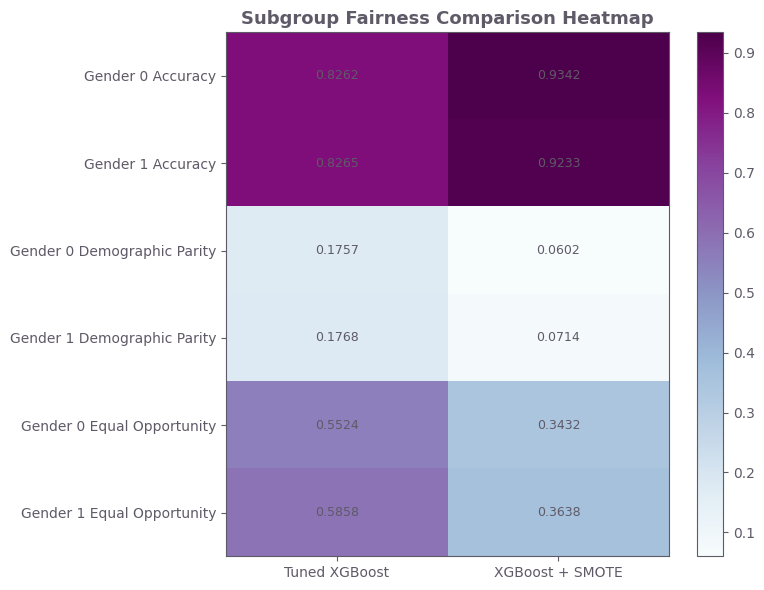

In [73]:
df_heat = fairness_subgroup_comparison.set_index("Metric")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(df_heat.values, cmap="BuPu", aspect="auto")

ax.set_xticks(np.arange(len(df_heat.columns)))
ax.set_xticklabels(df_heat.columns)

ax.set_yticks(np.arange(len(df_heat.index)))
ax.set_yticklabels(df_heat.index)

for i in range(df_heat.shape[0]):
    for j in range(df_heat.shape[1]):
        ax.text(
            j,
            i,
            f"{df_heat.iloc[i, j]:.4f}",
            ha="center",
            va="center",
            color=PALETTE["dark"],
            fontsize=9
        )

plt.title("Subgroup Fairness Comparison Heatmap")
plt.colorbar(im)
plt.tight_layout()
plt.show()

The heatmap provides a compact view of how the two models behave across gender groups. It shows that the differences are not extreme, but some subgroup variation remains, particularly in equal opportunity.

## Overall Comparison Summary

The tuned XGBoost model remained the strongest overall choice for this study. Although the XGBoost + SMOTE model improved accuracy, precision, and F1-score, it reduced recall, ROC-AUC, and PR-AUC, which made it less suitable for a sepsis prediction setting where identifying true positive cases is especially important.

From a fairness perspective, the SMOTE-based model showed a mixed outcome. It reduced the equal opportunity gap, but increased the gaps for equal accuracy and demographic parity. For that reason, the tuned XGBoost model without SMOTE was retained as the final model for reporting and fairness discussion.

## Local Explainability with LIME

The LIME explanations support the interpretability of the final tuned XGBoost model by showing which variables influenced selected predictions. Across the explained cases, variables such as ICULOS, Hour, HR, MAP, and HospAdmTime appeared repeatedly, which suggests that the model relied strongly on time-related ICU context and cardiovascular indicators.

In [74]:

# Use the already imputed data for LIME
X_train_lime = X_train_imputed.copy()
X_test_lime = X_test_imputed.copy()

constant_cols = [col for col in X_train_lime.columns if X_train_lime[col].nunique(dropna=False) <= 1]
X_train_lime = X_train_lime.drop(columns=constant_cols).copy()
X_test_lime = X_test_lime.drop(columns=constant_cols).copy()

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_lime.values,
    feature_names=X_train_lime.columns.tolist(),
    class_names=["No Sepsis", "Sepsis"],
    mode="classification",
    discretize_continuous=False,
    random_state=42
)

X_test_lime = X_test_lime.reset_index(drop=True)
y_test_lime = y_test.reset_index(drop=True)
y_pred_lime = pd.Series(y_pred_tuned_xgb).reset_index(drop=True)

true_positive_idx = ((y_test_lime == 1) & (y_pred_lime == 1)).idxmax()
false_negative_idx = ((y_test_lime == 1) & (y_pred_lime == 0)).idxmax()
false_positive_idx = ((y_test_lime == 0) & (y_pred_lime == 1)).idxmax()

exp_tp = lime_explainer.explain_instance(
    data_row=X_test_lime.iloc[true_positive_idx].values,
    predict_fn=tuned_xgb_model.predict_proba,
    num_features=8
)
exp_fn = lime_explainer.explain_instance(
    data_row=X_test_lime.iloc[false_negative_idx].values,
    predict_fn=tuned_xgb_model.predict_proba,
    num_features=8
)
exp_fp = lime_explainer.explain_instance(
    data_row=X_test_lime.iloc[false_positive_idx].values,
    predict_fn=tuned_xgb_model.predict_proba,
    num_features=8
)

print("True Positive LIME Explanation:")
for feature, weight in exp_tp.as_list():
    print(f"{feature}: {weight:.4f}")

print("\nFalse Negative LIME Explanation:")
for feature, weight in exp_fn.as_list():
    print(f"{feature}: {weight:.4f}")

print("\nFalse Positive LIME Explanation:")
for feature, weight in exp_fp.as_list():
    print(f"{feature}: {weight:.4f}")

True Positive LIME Explanation:
ICULOS: 0.0595
HR: 0.0473
Hour: 0.0433
MAP: -0.0259
HospAdmTime: -0.0194
SBP: -0.0088
Unit2: -0.0060
O2Sat: -0.0018

False Negative LIME Explanation:
HR: 0.0439
ICULOS: 0.0433
Hour: 0.0331
HospAdmTime: -0.0232
MAP: -0.0209
Age: -0.0057
Unit2: -0.0045
Unit1: 0.0030

False Positive LIME Explanation:
HR: 0.0450
ICULOS: 0.0378
Hour: 0.0326
HospAdmTime: -0.0256
MAP: -0.0232
Resp: 0.0192
Unit1: 0.0086
Unit2: -0.0042


d:\S3596833_Gollapalli_VasanthBoyez\S3596833_Gollapalli_VasanthBoyez\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
d:\S3596833_Gollapalli_VasanthBoyez\S3596833_Gollapalli_VasanthBoyez\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
d:\S3596833_Gollapalli_VasanthBoyez\S3596833_Gollapalli_VasanthBoyez\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


LIME is used here as a local interpretability tool.  
It does not improve model performance, but it helps explain which features influenced selected predictions from the final tuned XGBoost model.

## LIME Summary Table

| Case Type | Main Positive Contributors | Main Negative Contributors | Interpretation |
|---|---|---|---|
| True Positive | ICULOS, Hour, HR | MAP, HospAdmTime | The model correctly identified sepsis mainly based on ICU stay duration, time-related context, and heart rate. This suggests that it responded to signs of patient deterioration in a clinically meaningful way. |
| False Negative | ICULOS, HR, Hour | HospAdmTime, MAP, Age | The model detected some warning signals, especially ICU stay duration and heart rate, but these were not strong enough to push the prediction into the sepsis class. This helps explain why some genuine sepsis cases were still missed. |
| False Positive | HR, ICULOS, Hour, Resp | HospAdmTime, MAP | The model responded strongly to physiological stress indicators such as heart rate, ICU stay duration, and respiratory rate, even though the case was not septic. This suggests that some non-sepsis deterioration patterns may still trigger an alert. |

Across all three cases, the repeated appearance of **ICULOS, Hour, HR, MAP, and HospAdmTime** suggests that the model relied strongly on time-related ICU context and cardiovascular signals when making predictions.

## Final Tables

In [75]:
# Final performance table for selected final model
final_performance_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"],
    "Value": [acc_tuned, prec_tuned, rec_tuned, f1_tuned, roc_auc_tuned, pr_auc_tuned]
}).round(4)

final_performance_table.style \
    .set_caption("Final Performance Table: Tuned XGBoost") \
    .set_properties(**{
        "background-color": "#F6EAF4",
        "color": PALETTE["dark"],
        "border-color": PALETTE["grid"],
        "text-align": "center"
    }) \
    .set_table_styles([
        {"selector": "th", "props": [("background-color", PALETTE["primary"]),
                                     ("color", "white"),
                                     ("text-align", "center")]},
        {"selector": "caption", "props": [("color", PALETTE["dark"]),
                                          ("font-size", "13px"),
                                          ("font-weight", "bold")]}
    ])

,Metric,Value
0,Accuracy,0.826400
1,Precision,0.061500
2,Recall,0.572200
3,F1-score,0.111000
4,ROC-AUC,0.776300
5,PR-AUC,0.092600


In [76]:
# Final fairness table for tuned XGBoost
final_fairness_table = fairness_df_tuned.copy()

gap_row = pd.DataFrame([{
    "Gender": "Gap",
    "Accuracy": round(accuracy_gap, 6),
    "Demographic_Parity": round(dp_gap, 6),
    "Equal_Opportunity_TPR": round(eo_gap, 6),
    "TN": "",
    "FP": "",
    "FN": "",
    "TP": ""
}])

final_fairness_table = pd.concat([final_fairness_table, gap_row], ignore_index=True)

for col in ["Accuracy", "Demographic_Parity", "Equal_Opportunity_TPR"]:
    final_fairness_table[col] = final_fairness_table[col].apply(
        lambda x: round(x, 4) if isinstance(x, (int, float, np.floating)) else x
    )

final_fairness_table.style \
    .set_caption("Final Fairness Table: Tuned XGBoost by Gender") \
    .set_properties(**{
        "background-color": "#F6EAF4",
        "color": PALETTE["dark"],
        "border-color": PALETTE["grid"],
        "text-align": "center"
    }) \
    .set_table_styles([
        {"selector": "th", "props": [("background-color", PALETTE["secondary"]),
                                     ("color", PALETTE["dark"]),
                                     ("text-align", "center")]},
        {"selector": "caption", "props": [("color", PALETTE["dark"]),
                                          ("font-size", "13px"),
                                          ("font-weight", "bold")]}
    ])

,Gender,Accuracy,Demographic_Parity,Equal_Opportunity_TPR,TN,FP,FN,TP
0,0,0.826200,0.175700,0.552400,108147,21956,1072,1323
1,1,0.826500,0.176800,0.585800,144669,29349,1440,2037
2,Gap,0.000300,0.001100,0.033400,,,,


In [77]:
performance_comparison.style \
    .set_caption("Performance Comparison: Tuned XGBoost vs XGBoost + SMOTE") \
    .set_properties(**{
        "background-color": "#F6EAF4",
        "color": PALETTE["dark"],
        "border-color": PALETTE["grid"],
        "text-align": "center"
    }) \
    .set_table_styles([
        {"selector": "th", "props": [("background-color", PALETTE["primary"]),
                                     ("color", "white"),
                                     ("text-align", "center")]},
        {"selector": "caption", "props": [("color", PALETTE["dark"]),
                                          ("font-size", "13px"),
                                          ("font-weight", "bold")]}
    ])

,Metric,Tuned XGBoost,XGBoost + SMOTE
0,Accuracy,0.826400,0.928000
1,Precision,0.061500,0.101100
2,Recall,0.572200,0.355400
3,F1-score,0.111000,0.157500
4,ROC-AUC,0.776300,0.751700
5,PR-AUC,0.092600,0.080300


In [78]:
fairness_gap_comparison.style \
    .set_caption("Fairness Gap Comparison: Tuned XGBoost vs XGBoost + SMOTE") \
    .set_properties(**{
        "background-color": "#F6EAF4",
        "color": PALETTE["dark"],
        "border-color": PALETTE["grid"],
        "text-align": "center"
    }) \
    .set_table_styles([
        {"selector": "th", "props": [("background-color", PALETTE["secondary"]),
                                     ("color", PALETTE["dark"]),
                                     ("text-align", "center")]},
        {"selector": "caption", "props": [("color", PALETTE["dark"]),
                                          ("font-size", "13px"),
                                          ("font-weight", "bold")]}
    ])

,Fairness Metric,Tuned XGBoost,XGBoost + SMOTE
0,Equal Accuracy Gap,0.000300,0.010900
1,Demographic Parity Gap,0.001100,0.011200
2,Equal Opportunity Gap,0.033400,0.020600


### Model Card

In [79]:

model_card = f"""
MODEL CARD

1. Model Details
Model Name: Tuned XGBoost Sepsis Prediction Model
Model Type: XGBoost Classifier
Version: Final Tuned Version

2. Intended Use
This model was developed to predict sepsis risk from hourly patient-level clinical observations.
It is intended for academic experimentation and fairness evaluation only.
It should be treated as a decision-support model, not as an autonomous clinical decision-maker.

3. Dataset
Dataset Name: PhysioNet/Computing in Cardiology 2019 Challenge dataset
Target Variable: SepsisLabel
Protected Characteristic Used for Fairness Analysis: Gender
Unit of Analysis: Row-level hourly patient observations
Train-Test Split Method: Split by Patient_ID to avoid patient leakage

4. Input Features Used
{final_features}

5. Preprocessing
- Removed index-like column
- Removed highly sparse features
- Excluded Gender from model features and used it only for fairness evaluation
- Excluded Patient_ID from model training
- Median imputation applied to missing numerical values
- Used patient-level split to ensure no overlap between training and test patients

6. Final Tuned Parameters
n_estimators = 100
max_depth = 7
learning_rate = 0.03
min_child_weight = 5
subsample = 0.7
colsample_bytree = 0.7

7. Performance on Test Set
Accuracy: {acc_tuned:.4f}
Precision: {prec_tuned:.4f}
Recall: {rec_tuned:.4f}
F1-score: {f1_tuned:.4f}
ROC-AUC: {roc_auc_tuned:.4f}
PR-AUC: {pr_auc_tuned:.4f}

8. Fairness Evaluation by Gender
Gender 0 Accuracy: {fairness_df_tuned.loc[0, 'Accuracy']:.4f}
Gender 1 Accuracy: {fairness_df_tuned.loc[1, 'Accuracy']:.4f}
Gender 0 Demographic Parity: {fairness_df_tuned.loc[0, 'Demographic_Parity']:.4f}
Gender 1 Demographic Parity: {fairness_df_tuned.loc[1, 'Demographic_Parity']:.4f}
Gender 0 Equal Opportunity: {fairness_df_tuned.loc[0, 'Equal_Opportunity_TPR']:.4f}
Gender 1 Equal Opportunity: {fairness_df_tuned.loc[1, 'Equal_Opportunity_TPR']:.4f}

9. Limitations
- The dataset contains substantial missingness
- The model uses row-level observations rather than richer temporal features
- Performance remains constrained by class imbalance and feature sparsity
- Fairness was assessed using a single protected characteristic only

10. Recommendation
The tuned XGBoost model without SMOTE is retained as the final selected model because it gives the best overall balance for this sepsis prediction task.
"""

print(model_card)


MODEL CARD

1. Model Details
Model Name: Tuned XGBoost Sepsis Prediction Model
Model Type: XGBoost Classifier
Version: Final Tuned Version

2. Intended Use
This model was developed to predict sepsis risk from hourly patient-level clinical observations.
It is intended for academic experimentation and fairness evaluation only.
It should be treated as a decision-support model, not as an autonomous clinical decision-maker.

3. Dataset
Dataset Name: PhysioNet/Computing in Cardiology 2019 Challenge dataset
Target Variable: SepsisLabel
Protected Characteristic Used for Fairness Analysis: Gender
Unit of Analysis: Row-level hourly patient observations
Train-Test Split Method: Split by Patient_ID to avoid patient leakage

4. Input Features Used
['Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'Glucose', 'Age', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS']

5. Preprocessing
- Removed index-like column
- Removed highly sparse features
- Excluded Gender from model features and used it onl

## Final Conclusion

This study developed and evaluated a tuned XGBoost model for early sepsis prediction using hourly ICU observations. The final model performed better than the baseline and remained the strongest overall option after comparison with the additional SMOTE-based experiment.

Although the XGBoost + SMOTE model improved some overall metrics, it reduced recall and ranking performance, which made it less suitable for a high-risk sepsis setting. The final tuned XGBoost model therefore remained the selected model for fairness evaluation.

The fairness analysis showed that the final model was broadly balanced across gender under equal accuracy and demographic parity, but a modest gap remained under equal opportunity. This suggests that overall fairness was reasonably strong, but some subgroup difference in true sepsis detection still remained.

Finally, the LIME explanations helped improve transparency by showing which variables influenced selected individual predictions. Across the explained cases, ICU-related time variables and cardiovascular indicators appeared repeatedly, suggesting that the model relied strongly on clinically meaningful deterioration patterns.

Overall, the notebook shows that performance and fairness should be considered together when evaluating machine learning systems in healthcare.